In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

In [8]:
audio_file = 'yes/0a2b400e_nohash_2.wav'

In [11]:
# Read the wav file
# sample_rate is samples per second (Hz)
# data is the actual audio amplitude
sample_rate, data = wavfile.read(audio_file)

# If the audio is stereo (2 channels), convert to mono by averaging
if len(data.shape) > 1:
    data = data.mean(axis=1)

# Calculate time axis for the amplitude plot
duration = len(data) / sample_rate
print(f"Sample Rate: {sample_rate} Hz, Duration: {duration:.2f} seconds")

Sample Rate: 16000 Hz, Duration: 1.00 seconds


In [12]:
time = np.linspace(0., duration, len(data))

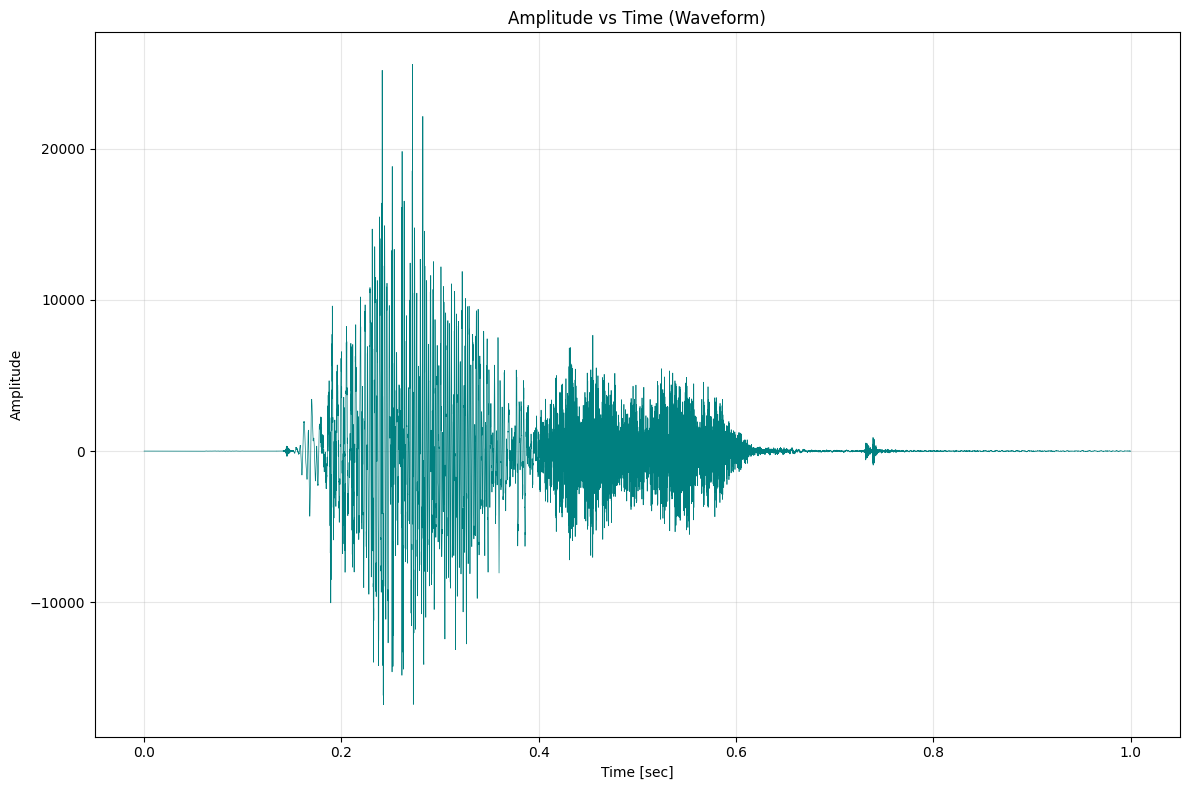

In [13]:
# Create the audio wave plot
# --- Plot Amplitude vs Time ---
fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

ax1.plot(time, data, color='teal', linewidth=0.5)
ax1.set_title('Amplitude vs Time (Waveform)')
ax1.set_ylabel('Amplitude')
ax1.set_xlabel('Time [sec]')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

In [14]:
# --- Compute the Spectrogram ---
# nperseg defines the length of each segment for the Fourier Transform
frequencies, times, spectrogram = signal.spectrogram(data, sample_rate)

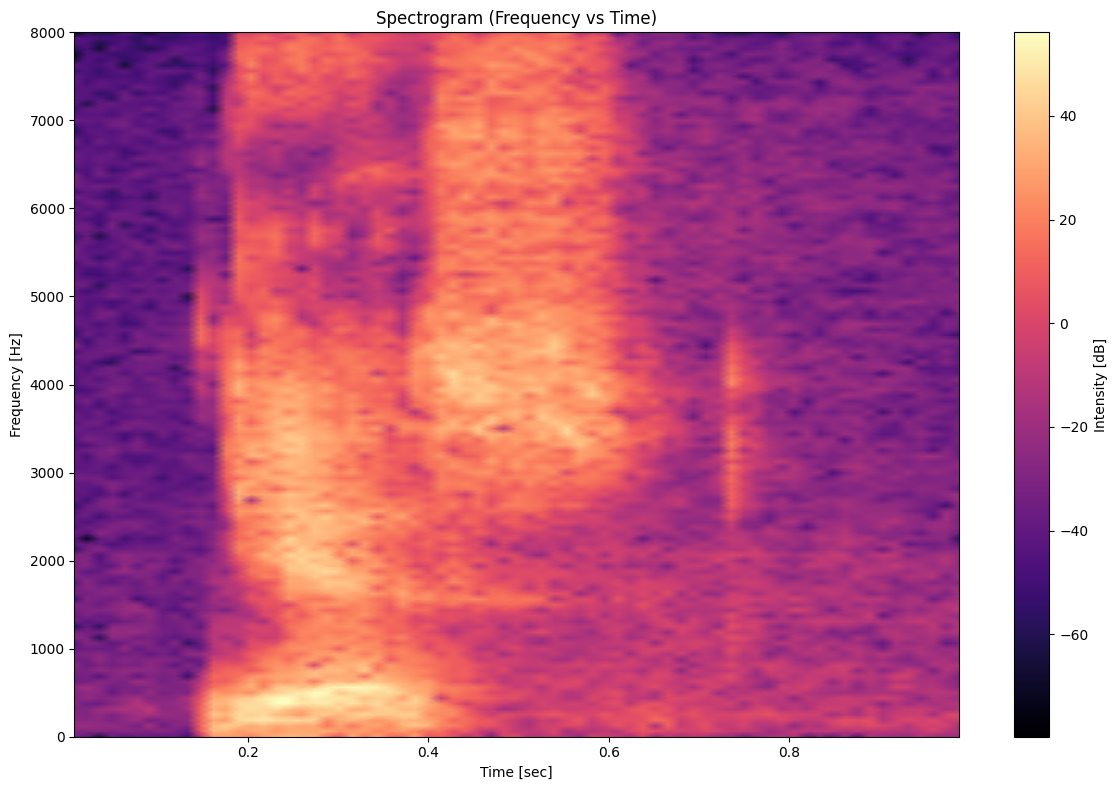

In [15]:
# Create the spectrogram plot
# --- Plot Amplitude vs Time ---
fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

# Use pcolormesh to plot the frequency intensities
# cmap='magma' or 'viridis' are great for visibility
im = ax1.pcolormesh(times, frequencies, 10 * np.log10(spectrogram),
                    shading='gouraud', cmap='magma')

ax1.set_title('Spectrogram (Frequency vs Time)')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_xlabel('Time [sec]')

# Add a colorbar to show intensity levels
fig.colorbar(im, ax=ax1, label='Intensity [dB]')

plt.tight_layout()
plt.show()
plt.close()